Fine-tuned BERT

Setup and Installation:

In [2]:
!pip -q install -U transformers datasets evaluate accelerate

In [3]:
import torch
import json
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)
from wordcloud import WordCloud, STOPWORDS

Load Data:


In [4]:
print("Loading data...")

# Load training data (Mendeley)
with open('../mendeley_cleaned.json', 'r', encoding='utf-8') as f:
    train_data = json.load(f)

# Load test data (Kaggle)
with open('../kaggle_data.json', 'r', encoding='utf-8') as f:
    test_data = json.load(f)

print(f"Training samples (Mendeley): {len(train_data):,}")
print(f"Test samples (Kaggle): {len(test_data):,}")

Loading data...
Training samples (Mendeley): 53,920
Test samples (Kaggle): 117,458


In [5]:
# Prepare data
# Mendeley: 'review' + 'recommend'
X_all = [item["review"] for item in train_data]
y_all = [1 if item["recommend"] == "Recommended" else 0 for item in train_data]

# Kaggle: 'review_content' + 'is_positive'
X_test = [item["review_content"] for item in test_data]
y_test = [1 if item["is_positive"] else 0 for item in test_data]

print(f"Mendeley - Positive: {sum(y_all):,}, Negative: {len(y_all) - sum(y_all):,}")
print(f"Kaggle   - Positive: {sum(y_test):,}, Negative: {len(y_test) - sum(y_test):,}")

# Split Mendeley into train/val (stratified)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print(f"Mendeley split -> Train: {len(X_train):,}, Val: {len(X_val):,}")

Mendeley - Positive: 26,960, Negative: 26,960
Kaggle   - Positive: 55,789, Negative: 61,669
Mendeley split -> Train: 43,136, Val: 10,784


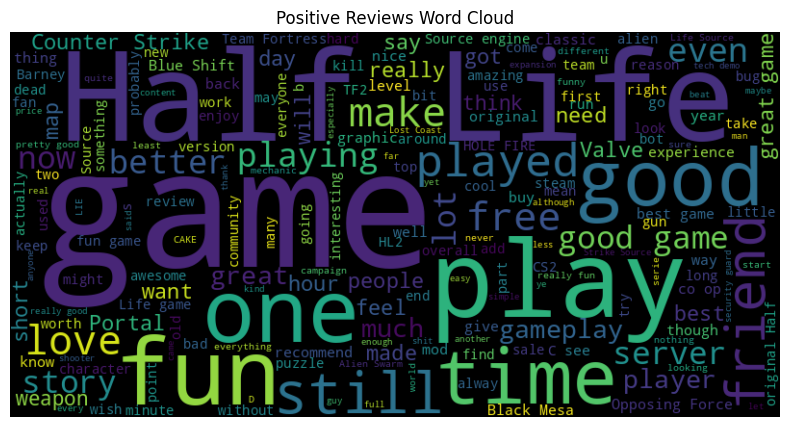

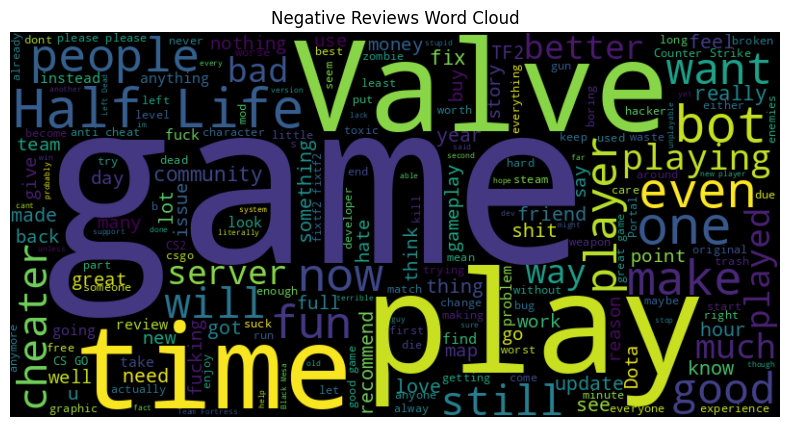

In [27]:
# Word cloud data analysis:

positive_reviews = [text for text, label in zip(X_test, y_test) if label == 1]
negative_reviews = [text for text, label in zip(X_test, y_test) if label == 0]

def generate_wordcloud(text,Title):
    all_text = " ".join(text)
    wordcloud = WordCloud(width=800,
                          height=400,
                          stopwords=set(STOPWORDS),
                          background_color='black').generate(all_text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(Title)
    plt.show()

generate_wordcloud(positive_reviews, "Positive Reviews Word Cloud")
generate_wordcloud(negative_reviews, "Negative Reviews Word Cloud")

Tokenize Text for BERT (with some notes for learning purposes):

- BERT's own tokenizer splits words into subwords or workpieces, with a "##" prefiix to indicate that a subword is a continuation of the previous one.

- Example: "UCIvine" -> "UC", "##Irvine"

Special tokens added by the BERT tokenizer - CLS, SEP, MASK:

- CLS: classification
- SEP: separator
- MASK: mask some tokens from the model during pre-training

In [8]:
checkpoint = "bert-base-uncased"  # should try bert-large-cased
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

MAX_LEN = 512

train_ds = Dataset.from_dict({"text": X_train, "label": y_train})
val_ds   = Dataset.from_dict({"text": X_val,   "label": y_val})
test_ds  = Dataset.from_dict({"text": X_test,  "label": y_test})

def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

train_tok = train_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
val_tok   = val_ds.map(tokenize_batch, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# print("Example tokenized row:", train_tok[0].keys())

Map:   0%|          | 0/43136 [00:00<?, ? examples/s]

Map:   0%|          | 0/10784 [00:00<?, ? examples/s]

Map:   0%|          | 0/117458 [00:00<?, ? examples/s]

Example tokenized row: dict_keys(['label', 'input_ids', 'token_type_ids', 'attention_mask'])


In [13]:
# Tokenization Example
example = X_train[0]

encoded = tokenizer(example)

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print("Example review:")
print(example)

print("\nTokenized:")
print(f"First 10 tokens -", tokens[:10])
print(f"Last 10 tokens -", tokens[-10:])

Example review:
The conecpt is there but the game is incredibly unplayable. Matching making is broken and hardly works half the time. Frequently get booted randomly from matchs. Often the game stops taking input from the keyboard and mouse. I would pass for now, wait until Ubisoft finishes the game, that is if they even do.UPDATE: 2/25/2017 Some changes have come to the game, its making progress, I would highly recommend having a game controller, just a prefrence though. However the game still has massive server issues, and the peer to peer connection has got to go. A new issue that happens now is occasionally all players are booted and replaced with bots.UPDATE: 3/12/2017 Changes are coming to the game, I hope that it will move in the right direction. As of now its a fun game, but still needs a lot of help in the connection department.

Tokenized:
First 10 tokens - ['[CLS]', 'the', 'cone', '##cp', '##t', 'is', 'there', 'but', 'the', 'game']
Last 10 tokens - ['a', 'lot', 'of', 'help', 

Train Model: Fine-tune BERT
- Use pretrained BERT model (BertForSequenceClassification)

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

training_args = TrainingArguments(
    output_dir="./bert_mendeley_ft",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3, # analyze the different number of epochs(?)
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),
    logging_steps=50,
    save_total_limit=2,
    report_to="none"
)

trainer = Trainer( # finetune using HuggingFace Trainer API
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

trainer.train()
print("Training complete!")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.251906,0.301036,0.881677,0.860799,0.910608,0.885004
2,0.235446,0.301341,0.885942,0.879745,0.894102,0.886865
3,0.124621,0.457433,0.885849,0.887936,0.883160,0.885542


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training complete!


Testing on Kaggle dataset:


In [18]:
# Full test set

# test_metrics = trainer.evaluate(test_tok)
# print(test_metrics)

pred_out = trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("=" * 50)
print(f"EVALUATION ON WHOLE KAGGLE DATASET")
print("=" * 50)
print(f"\nAccuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
0,0.184025,0.491953,0.850994,0.835222,0.854953,0.844972


{'eval_loss': 0.4919525384902954, 'eval_accuracy': 0.8509935466294335, 'eval_precision': 0.8352216015549757, 'eval_recall': 0.8549534854541218, 'eval_f1': 0.8449723639455783}
EVALUATION ON WHOLE KAGGLE DATASET

Accuracy:  0.8510
Precision: 0.8352
Recall:    0.8550
F1 Score:  0.8450

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     61669
    Positive       0.84      0.85      0.84     55789

    accuracy                           0.85    117458
   macro avg       0.85      0.85      0.85    117458
weighted avg       0.85      0.85      0.85    117458



--- Confusion Matrix ---
[[52259  9410]
 [ 8092 47697]]


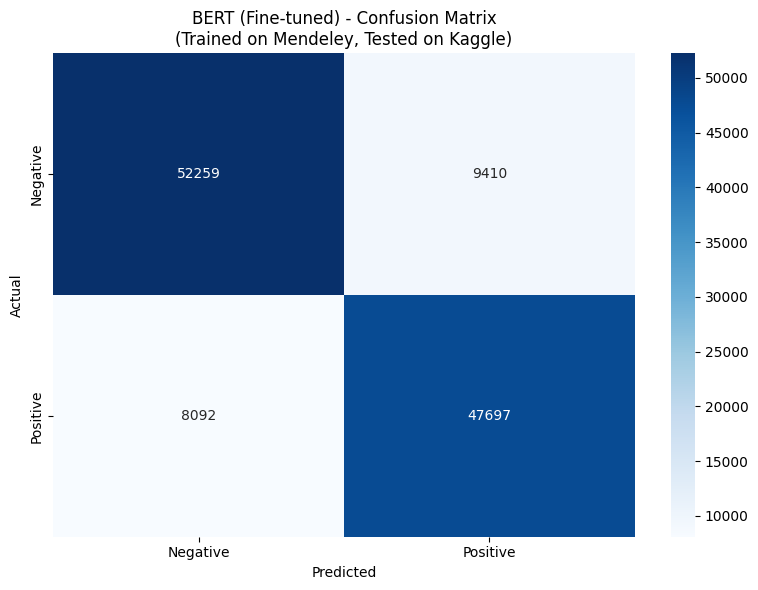

In [19]:
cm = confusion_matrix(y_test, y_pred)
print("--- Confusion Matrix ---")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("BERT (Fine-tuned) - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle)")
plt.tight_layout()
plt.show()

In [20]:
import random

print("Testing on Subset (2000 samples from Kaggle)")

random.seed(42)

pos_idx = [i for i, y in enumerate(y_test) if y == 1]
neg_idx = [i for i, y in enumerate(y_test) if y == 0]

N = 2000
half = N // 2

idx = random.sample(pos_idx, half) + random.sample(neg_idx, N - half)
random.shuffle(idx)

X_test_sub = [X_test[i] for i in idx]
y_test_sub = [y_test[i] for i in idx]

print("Subset size:", len(y_test_sub))
print("Subset pos:", sum(y_test_sub), "neg:", len(y_test_sub) - sum(y_test_sub))

sub_ds = Dataset.from_dict({"text": X_test_sub, "label": y_test_sub})
sub_tok = sub_ds.map(tokenize_batch, batched=True, remove_columns=["text"])

pred_sub = trainer.predict(sub_tok)
y_pred_sub = np.argmax(pred_sub.predictions, axis=-1)

accuracy_sub = accuracy_score(y_test_sub, y_pred_sub)
precision_sub = precision_score(y_test_sub, y_pred_sub, zero_division=0)
recall_sub = recall_score(y_test_sub, y_pred_sub, zero_division=0)
f1_sub = f1_score(y_test_sub, y_pred_sub, zero_division=0)

print("=" * 50)
print(f"EVALUATION ON KAGGLE SUBSET (N={N})")
print("=" * 50)
print(f"\nAccuracy:  {accuracy_sub:.4f}")
print(f"Precision: {precision_sub:.4f}")
print(f"Recall:    {recall_sub:.4f}")
print(f"F1 Score:  {f1_sub:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test_sub, y_pred_sub, target_names=["Negative", "Positive"]))

print("\n--- Comparison with Full Test Set ---")
print(f"Full dataset accuracy:    {accuracy:.4f}")
print(f"Subset (N={N}) accuracy:  {accuracy_sub:.4f}")
print(f"Difference: {accuracy_sub - accuracy:+.4f}")

Testing on Subset (2000 samples from Kaggle)
Subset size: 2000
Subset pos: 1000 neg: 1000


Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
0,0.184025,0.491953,0.850994,0.835222,0.854953,0.844972


EVALUATION ON KAGGLE SUBSET (N=2000)

Accuracy:  0.8575
Precision: 0.8522
Recall:    0.8650
F1 Score:  0.8586

--- Classification Report ---
              precision    recall  f1-score   support

    Negative       0.86      0.85      0.86      1000
    Positive       0.85      0.86      0.86      1000

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000


--- Comparison with Full Test Set ---
Full dataset accuracy:    0.8510
Subset (N=2000) accuracy:  0.8575
Difference: +0.0065


--- Confusion Matrix (N=2000 Subset) ---
[[850 150]
 [135 865]]


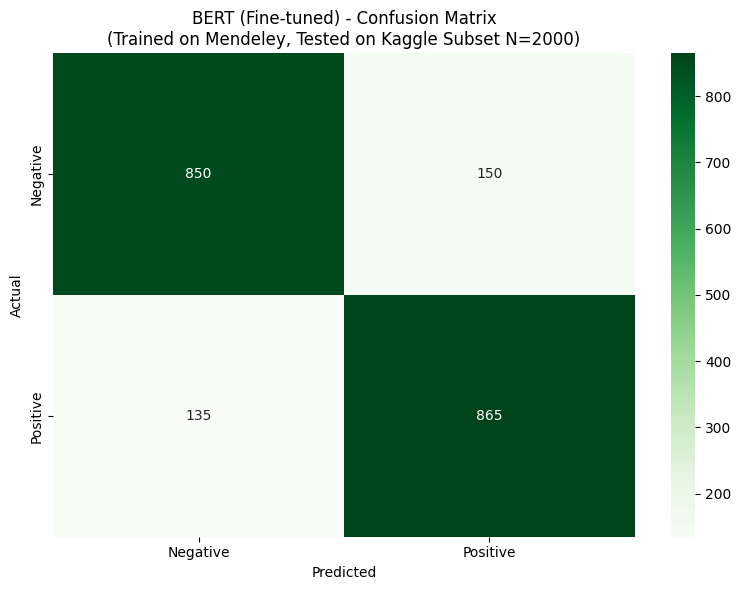

In [21]:
cm_sub = confusion_matrix(y_test_sub, y_pred_sub)
print("--- Confusion Matrix (N=2000 Subset) ---")
print(cm_sub)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_sub, annot=True, fmt="d", cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"BERT (Fine-tuned) - Confusion Matrix\n(Trained on Mendeley, Tested on Kaggle Subset N={N})")
plt.tight_layout()
plt.show()